In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.preprocessing import StandardScaler
import kagglehub
import plotly.express as px
import os

In [40]:
path = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

pliki = os.listdir(path)
csv_path = os.path.join(path, pliki[0])
df = pd.read_csv(csv_path)
df.head(2)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1


In [41]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 97.6 KB


In [42]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


<Axes: xlabel='HeartDisease', ylabel='count'>

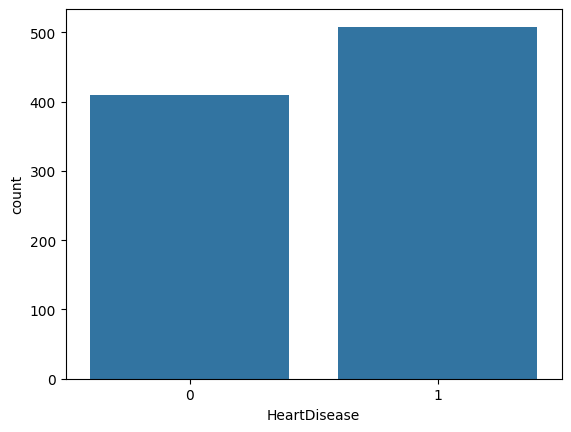

In [43]:
sns.countplot(df, x='HeartDisease')

<Axes: xlabel='Sex', ylabel='count'>

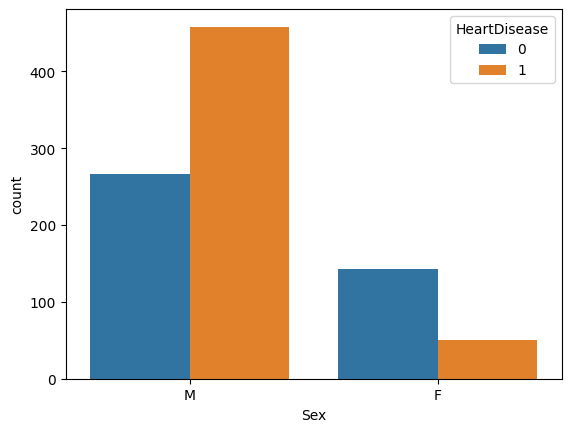

In [44]:
sns.countplot(df, x='Sex', hue='HeartDisease')

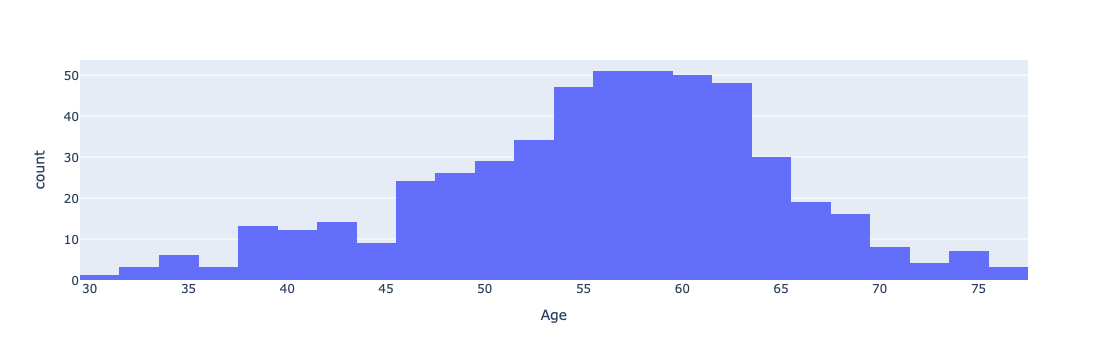

In [45]:
px.histogram(df[df['HeartDisease'] == 1], x='Age')

In [46]:
df.groupby('HeartDisease')[['Age', 'MaxHR', 'Oldpeak']].mean().round(2)

,Age,MaxHR,Oldpeak
HeartDisease,,,
0,50.55,148.15,0.41
1,55.90,127.66,1.27


In [47]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [48]:
str_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in str_cols:
    print(f"{col}: {df[col].unique()}")

Sex: <ArrowStringArray>
['M', 'F']
Length: 2, dtype: str
ChestPainType: <ArrowStringArray>
['ATA', 'NAP', 'ASY', 'TA']
Length: 4, dtype: str
RestingECG: <ArrowStringArray>
['Normal', 'ST', 'LVH']
Length: 3, dtype: str
ExerciseAngina: <ArrowStringArray>
['N', 'Y']
Length: 2, dtype: str
ST_Slope: <ArrowStringArray>
['Up', 'Flat', 'Down']
Length: 3, dtype: str


In [49]:
df['Sex'] = (df['Sex'] =='M').astype(int)
df['ExerciseAngina'] = (df['ExerciseAngina'] =='Y').astype(int)

In [50]:
df = pd.get_dummies(df, columns=['ChestPainType', 'RestingECG', 'ST_Slope'], drop_first=True)
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [51]:
df.head(2)

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289,0,172,0,0.0,0,1,0,0,1,0,0,1
1,49,0,160,180,0,156,0,1.0,1,0,1,0,1,0,1,0


In [52]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [53]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

In [54]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [55]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression

In [56]:
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [57]:
model_lr = LogisticRegression(max_iter=100, random_state=42)
model_lr.fit(X_train_scaled, y_train) 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [58]:
y_pred_lr = model_lr.predict(X_test_scaled)

In [62]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

def evaluate_classification(y_test, y_pred, model_name):
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    print(f"\n=== {model_name} ===")
    print(f"Accuracy: {acc:.4f}")
    print(f"F1:       {f1:.4f}")
    print(f"Recall:   {recall:.4f}")


In [63]:
evaluate_classification(y_test, y_pred_lr, 'Logistic Regression')


=== Logistic Regression ===
Accuracy: 0.8841
F1:       0.8981
Recall:   0.9216


# Random forest

In [64]:
from sklearn.ensemble import RandomForestClassifier

In [69]:
for depth in [3,5,7,10,19,25]:
    rfc = RandomForestClassifier(max_depth=depth, random_state=42)
    rfc.fit(X_train_scaled,y_train)
    y_pred_rfc = rfc.predict(X_test_scaled)
    recall_rfc = recall_score(y_test, y_pred_rfc)
    accuracy_rfc = accuracy_score(y_test,y_pred_rfc)
    print(f"max_depth={depth}: recall={recall_rfc:.4f}, acc = {accuracy_rfc}")

max_depth=3: recall=0.9150, acc = 0.8586956521739131
max_depth=5: recall=0.9216, acc = 0.8840579710144928
max_depth=7: recall=0.9150, acc = 0.8913043478260869
max_depth=10: recall=0.9150, acc = 0.894927536231884
max_depth=19: recall=0.9150, acc = 0.8913043478260869
max_depth=25: recall=0.9150, acc = 0.8913043478260869


In [73]:
for n in [50, 100, 200, 300, 500,700]:
    rfc = RandomForestClassifier(n_estimators=n, max_depth=10,random_state=42)
    rfc.fit(X_train_scaled, y_train)
    y_pred_rfc = rfc.predict(X_test_scaled)
    recall_rfc = recall_score(y_test, y_pred_rfc)
    accuracy_rfc = accuracy_score(y_test,y_pred_rfc)
    print(f"n_estimators={n}: recall={recall_rfc:.4f}, acc = {accuracy_rfc}")

n_estimators=50: recall=0.9020, acc = 0.8913043478260869
n_estimators=100: recall=0.9150, acc = 0.894927536231884
n_estimators=200: recall=0.9216, acc = 0.9021739130434783
n_estimators=300: recall=0.9150, acc = 0.8985507246376812
n_estimators=500: recall=0.9216, acc = 0.9057971014492754
n_estimators=700: recall=0.9216, acc = 0.8985507246376812


In [74]:
model_rf = RandomForestClassifier(max_depth=10, n_estimators=500,random_state=42)
model_rf.fit(X_train_scaled, y_train)
y_pred_rf = model_rf.predict(X_test_scaled)

In [75]:
evaluate_classification(y_test, y_pred_rf, 'Random forest')


=== Random forest ===
Accuracy: 0.9058
F1:       0.9156
Recall:   0.9216


# KNN

In [76]:
from sklearn.neighbors import KNeighborsClassifier

In [82]:
error_rate =[]

for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train_scaled,y_train)
    y_pred_knn = knn.predict(X_test_scaled)
    error_rate.append(np.mean(y_pred_knn != y_test))

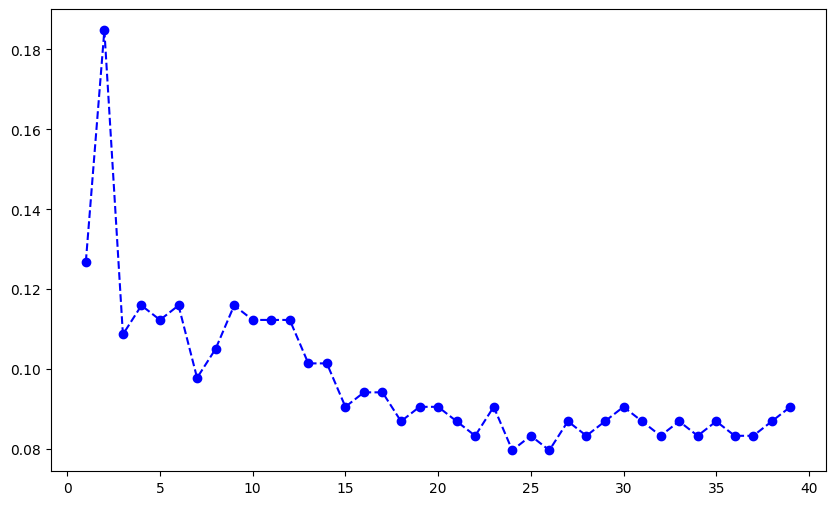

In [78]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, color='blue', ls='dashed', marker='o')


In [83]:
best_k = error_rate.index(min(error_rate)) + 1
print(f"best k = {best_k}")

best k = 24


In [84]:
knn = KNeighborsClassifier(n_neighbors=24)
knn.fit(X_train_scaled,y_train)
y_pred_knn = knn.predict(X_test_scaled)

In [85]:
evaluate_classification(y_test, y_pred_knn, 'KNN')


=== KNN ===
Accuracy: 0.9203
F1:       0.9281
Recall:   0.9281


# Gaussian NB

In [86]:
from sklearn.naive_bayes import GaussianNB

In [87]:
nb = GaussianNB()
nb.fit(X_train_scaled,y_train)
y_pred_nb = nb.predict(X_test_scaled)

In [95]:
evaluate_classification(y_test, y_pred_nb, 'GaussianNB')


=== GaussianNB ===
Accuracy: 0.9022
F1:       0.9109
Recall:   0.9020


# XGBOOST

In [98]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

In [103]:
parad_grid = {
    'n_estimators': [100, 200, 300,400],
    'max_depth': [2,3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
}

xgb = XGBClassifier(random_state = 42, eval_metric = 'logloss')
grid_search = GridSearchCV(xgb, parad_grid, cv=5,scoring='accuracy',  n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f"Best params: {grid_search.best_params_}")
print(f"Best accuracy : {grid_search.best_score_:.4f}")

Best params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300}
Best accuracy : 0.8598


In [106]:
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric='logloss'
)

model_xgb.fit(X_train_scaled, y_train)
y_pred_xgb = best_xgb.predict(X_test_scaled)
evaluate_classification(y_test, y_pred_xgb, "XGBoost")


=== XGBoost ===
Accuracy: 0.8841
F1:       0.8940
Recall:   0.8824


# SUMMARY

In [96]:
results = {}

results['Linear Regression'] = evaluate_classification(y_test, y_pred_lr, "Linear Regression")
results['Random Forest'] = evaluate_classification(y_test, y_pred_rf, "Random Forest")
results['KNN'] = evaluate_classification(y_test, y_pred_knn, "KNN")
results['GaussianNB'] = evaluate_classification(y_test, y_pred_nb, "GaussianNB")


print("-" * 46)
for model_name, metrics in results.items():
    print(f"{model_name:<20}")


=== Linear Regression ===
Accuracy: 0.8841
F1:       0.8981
Recall:   0.9216

=== Random Forest ===
Accuracy: 0.9058
F1:       0.9156
Recall:   0.9216

=== KNN ===
Accuracy: 0.9203
F1:       0.9281
Recall:   0.9281

=== GaussianNB ===
Accuracy: 0.9022
F1:       0.9109
Recall:   0.9020
----------------------------------------------
Linear Regression   
Random Forest       
KNN                 
GaussianNB          


In [97]:
# KNN is the best model 